# **C01-C02 - Números pseudoaleatorios y generadores congruenciales**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 17 y 19 de agosto de 2026

---

En este notebook se estima por simulación la probabilidad de un evento cuyo valor exacto puede calcularse de forma combinatoria, y en seguida se construyen generadores congruenciales lineales para examinar bajo qué condiciones producen un ciclo completo, con el propósito de entender qué sostiene a los números pseudoaleatorios que después alimentan cualquier simulación financiera.

## Índice de contenidos

1. Sección 1 — Probabilidad de tres tiradas crecientes
2. Sección 2 — Generador congruencial de ciclo completo
3. Sección 3 — Generador de periodo largo y reescalamiento
4. Sección 4 — Conclusiones

## Importación de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd

np.random.seed(17)

## 1. Probabilidad de tres tiradas crecientes

**Ejercicio:** calcular la probabilidad de que al lanzar tres dados cada tirada tenga un valor mayor al de la tirada previa.

El experimento se repite en 100,000 universos independientes y se cuenta la proporción en que se cumple la condición, procedimiento que puede contrastarse con el resultado exacto, ya que la secuencia debe ser estrictamente creciente y por ello equivale a elegir tres caras distintas de seis en un único orden posible, es decir, $\binom{6}{3}/6^3 = 20/216$.

In [2]:
universos = 100000
caras = (1, 2, 3, 4, 5, 6)
exitos = 0

for universo in range(universos):
    tirada_1 = np.random.choice(caras)
    tirada_2 = np.random.choice(caras)
    tirada_3 = np.random.choice(caras)

    if tirada_1 < tirada_2 and tirada_2 < tirada_3:
        exitos = exitos + 1

probabilidad_simulada = exitos / universos
probabilidad_teorica = 20 / 216

print(f"Casos favorables: {exitos}")
print(f"Probabilidad simulada: {probabilidad_simulada:.5f}")
print(f"Probabilidad teórica 20/216: {probabilidad_teorica:.5f}")
print(f"Diferencia absoluta: {abs(probabilidad_simulada - probabilidad_teorica):.5f}")

Casos favorables: 9229
Probabilidad simulada: 0.09229
Probabilidad teórica 20/216: 0.09259
Diferencia absoluta: 0.00030


La simulación arroja 9,229 casos favorables sobre 100,000 universos, es decir, una probabilidad de 0.09229 frente a los 0.09259 del cálculo combinatorio, con una diferencia de 0.00030 que representa apenas 0.32% del valor exacto, y esa cercanía confirma que el conteo por fuerza bruta converge al resultado analítico cuando el número de repeticiones es suficientemente grande, ya que cada universo es una realización independiente del mismo experimento.

Conviene notar que el evento resulta mucho menos frecuente de lo que sugiere la intuición, pues apenas uno de cada once intentos cumple la condición, y la razón está en la exigencia de crecimiento estricto, la cual descarta cualquier repetición y deja únicamente 20 arreglos válidos de los 216 posibles, uno por cada terna de caras distintas y en un solo orden de los seis en que podría presentarse.

## 2. Generador congruencial de ciclo completo

**Ejercicio:** construir un generador de ciclo completo con los valores indicados en clase.

Un generador congruencial lineal produce cada término a partir del anterior mediante una multiplicación, una suma y un residuo, de modo que la secuencia queda totalmente determinada por la semilla y por los tres parámetros.

$$X_{i+1} = (aX_i + b) \bmod m$$

Se dice que el generador es de ciclo completo cuando recorre los $m$ valores posibles antes de repetirse, condición que se cumple si $m$ y $b$ son primos entre sí, si todo primo $q$ que divide a $m$ divide también a $a-1$ y si, en caso de que 4 divida a $m$, también divida a $a-1$.

In [3]:
a = 5
b = 3
m = 16
X = 7

resultados = []

for iteracion in range(50):
    X = (a * X + b) % m
    resultados.append(X)

print("Primeros 16 valores:", resultados[:16])
print("Siguientes 16 valores:", resultados[16:32])
print(f"Valores distintos en el primer ciclo: {len(set(resultados[:m]))} de {m} posibles")
print(f"La secuencia se repite con periodo {m}: {resultados[:m] == resultados[m:2 * m]}")
print()
print(f"Condición 1, m y b primos entre sí: {gcd(m, b) == 1}")
print(f"Condición 2, todo primo que divide a m divide a a-1: {(a - 1) % 2 == 0}")
print(f"Condición 3, si 4 divide a m entonces divide a a-1: {(a - 1) % 4 == 0}")

Primeros 16 valores: [6, 1, 8, 11, 10, 5, 12, 15, 14, 9, 0, 3, 2, 13, 4, 7]
Siguientes 16 valores: [6, 1, 8, 11, 10, 5, 12, 15, 14, 9, 0, 3, 2, 13, 4, 7]
Valores distintos en el primer ciclo: 16 de 16 posibles
La secuencia se repite con periodo 16: True

Condición 1, m y b primos entre sí: True
Condición 2, todo primo que divide a m divide a a-1: True
Condición 3, si 4 divide a m entonces divide a a-1: True


El generador recorre los dieciséis valores posibles antes de repetirse, ya que el primer ciclo contiene 16 valores distintos de 16 posibles y la comparación entre el primer bloque y el segundo devuelve verdadero, con lo cual la secuencia queda completamente determinada a partir de la iteración dieciséis y desde ahí sólo repite el mismo recorrido.

Las tres condiciones se verifican por separado y también resultan verdaderas, pues 16 y 3 no comparten divisores, el único primo que divide a 16 es 2 y divide a $a-1 = 4$, y dado que 4 divide a 16 también debe dividir a 4, lo cual ocurre, de manera que el comportamiento observado no es una casualidad de la semilla elegida sino la consecuencia esperada del cumplimiento del criterio.

## 3. Generador de periodo largo y reescalamiento

**Ejercicio:** generar una secuencia con los parámetros indicados en clase y graficarla para obtener conclusiones.

Los parámetros cambian de escala por completo, ya que el módulo pasa a ser el primo de Mersenne $2^{31}-1$, con lo cual el generador deja de poder inspeccionarse a mano y sólo puede evaluarse por el comportamiento estadístico de la muestra que produce.

In [4]:
a = 12345
b = 1103515245
m = 2 ** 31 - 1
X = 739214

resultados = []

for iteracion in range(10 ** 4):
    X = (a * X + b) % m
    resultados.append(X)

print(f"Valores generados: {len(resultados)}")
print(f"Valores distintos: {len(set(resultados))}")
print(f"Condición 1, m y b primos entre sí: {gcd(m, b) == 1}")
print(f"Condición 2, el único primo que divide a m es m y divide a a-1: {(a - 1) % m == 0}")

Valores generados: 10000
Valores distintos: 10000
Condición 1, m y b primos entre sí: True
Condición 2, el único primo que divide a m es m y divide a a-1: False


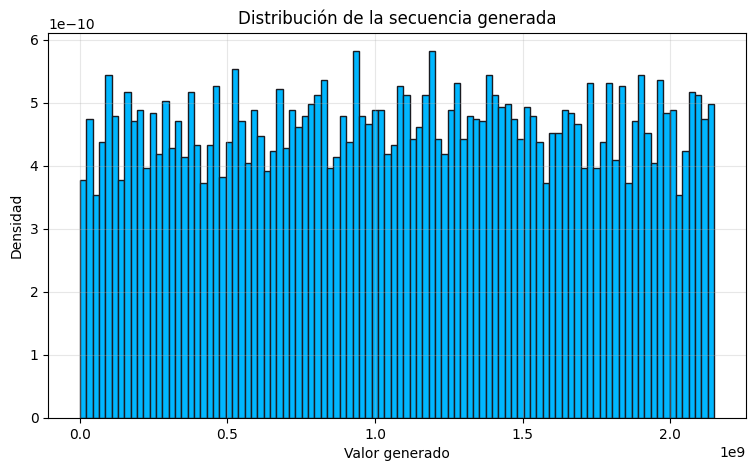

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(resultados, bins=100, density=True, color="#00B7FF", edgecolor="#1A1B21")

plt.title("Distribución de la secuencia generada")
plt.xlabel("Valor generado")
plt.ylabel("Densidad")
plt.grid(alpha=0.3)
plt.show()

Los 10,000 valores generados resultan todos distintos y el histograma se reparte de forma pareja sobre el rango del módulo, lo cual sugiere uniformidad, aunque el resultado exige una advertencia importante, ya que la segunda condición de ciclo completo no se cumple: al ser $m = 2^{31}-1$ un número primo, el único primo que lo divide es él mismo y tendría que dividir a $a-1 = 12{,}344$, cosa que evidentemente no ocurre.

De ahí se desprende la lección del ejercicio, pues un generador puede producir una muestra de apariencia uniforme sin tener periodo completo, es decir, la uniformidad observada en 10,000 extracciones es una propiedad mucho más débil que la garantía de recorrer los $m$ estados, y por ello la inspección visual del histograma nunca sustituye a la verificación de las condiciones.

El uso práctico de un generador rara vez ocurre en la escala del módulo, por ello la secuencia se lleva al intervalo objetivo mediante una transformación afín que traslada el mínimo a 2 y el máximo a 5.

$$U_i = \frac{X_i - \min(X)}{\max(X) - \min(X)}\,(5-2) + 2$$

Valor mínimo tras el reescalamiento: 2.000000
Valor máximo tras el reescalamiento: 5.000000
Media observada: 3.511824
Media teórica de una uniforme en [2, 5]: 3.500000


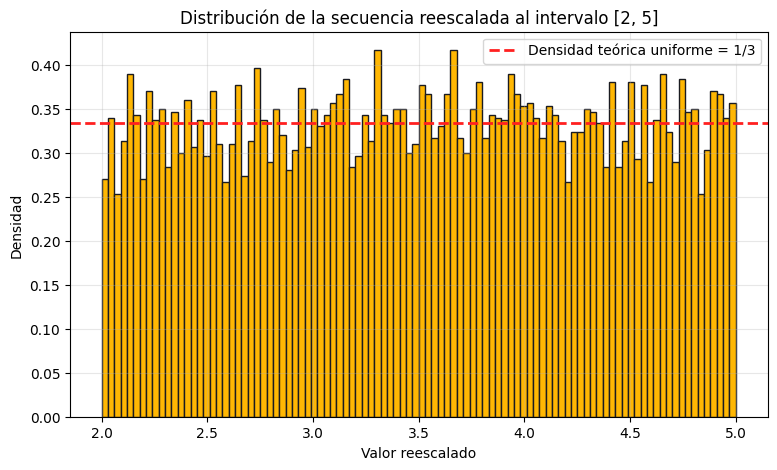

In [6]:
resultados = np.array(resultados)
reescalados = ((resultados - min(resultados)) / (max(resultados) - min(resultados))) * 3 + 2

print(f"Valor mínimo tras el reescalamiento: {reescalados.min():.6f}")
print(f"Valor máximo tras el reescalamiento: {reescalados.max():.6f}")
print(f"Media observada: {reescalados.mean():.6f}")
print(f"Media teórica de una uniforme en [2, 5]: {3.5:.6f}")

plt.figure(figsize=(9, 5))
plt.hist(reescalados, bins=100, density=True, color="#FFB703", edgecolor="#1A1B21")
plt.axhline(1 / 3, color="#FF2020", linestyle="--", linewidth=2,
            label="Densidad teórica uniforme = 1/3")

plt.title("Distribución de la secuencia reescalada al intervalo [2, 5]")
plt.xlabel("Valor reescalado")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La transformación afín lleva el mínimo exactamente a 2 y el máximo exactamente a 5, mientras la media observada de 3.511824 queda 0.011824 por encima del centro teórico de 3.5, diferencia pequeña que refleja la dispersión propia de una muestra finita y no un sesgo del procedimiento, ya que al ser lineal la transformación preserva la forma de la distribución original y por eso la densidad se mantiene cerca del valor 1/3 que corresponde a una uniforme sobre un intervalo de longitud tres.

## 4. Conclusiones

El primer ejercicio muestra que la simulación reproduce un resultado combinatorio conocido con un error de 0.00030 sobre 100,000 repeticiones, lo cual funciona como calibración del método, ya que cuando el valor exacto es verificable la simulación puede validarse, y es justamente esa validación la que después permite confiar en el mismo procedimiento frente a problemas donde no existe fórmula cerrada.

El segundo y el tercer ejercicio separan dos propiedades que suelen confundirse, pues el generador pequeño cumple las tres condiciones y recorre sus dieciséis estados, mientras el de módulo primo incumple la segunda y aun así entrega una muestra de aspecto uniforme, de modo que periodo completo y uniformidad observada no son lo mismo.

La implicación metodológica es directa, ya que toda simulación financiera descansa sobre la calidad del generador subyacente, y un periodo insuficiente frente al número de extracciones introduciría dependencia entre trayectorias que ningún histograma alcanzaría a revelar, por ello conviene documentar siempre la semilla y verificar las condiciones antes de confiar en los resultados de una corrida extensa.

El límite del análisis está en que la evaluación se apoyó en un solo criterio, y una revisión más rigurosa exigiría pruebas específicas de aleatoriedad como la de rachas o la de correlación serial, además de medir el periodo real del segundo generador en lugar de constatar únicamente que no se repite dentro de las primeras 10,000 extracciones.